#Notebook Description
This notebook trains a CNN to classify modulation schemes given IQ data.

This CNN is based on the following work:
- https://www.mdpi.com/2079-9292/12/18/3962
- https://github.com/caharper/Automatic-Modulation-Classification-with-Deep-Neural-Networks

Dataset used: https://www.kaggle.com/datasets/pinxau1000/radioml2018

It is built upon Harper's best CNN design utilizing dilated convolutions, statistics pooling, and SE blocks. Harper's CNN is built using Tensorflow. For ease, this notebook aims to replicate it in PyTorch.

This notebook is split into sections:
1. Dataset class: reads one (IQ frame, label, SNR) triplet from the hdf5 file per index
2. Train/val/test split: SNR stratified indices so all splits cover the full -20 to +30 dB range evenly, saved once so they're reproducible
3. DataLoader sanity check: pulls one batch, confirms shapes/dtypes, visualizes a couple IQ waveforms
4. Model architecture: PyTorch port of Harper's best design mentioned in the paper
5. Training loop: loss (cross-entropy), optimizer, epoch loop, checkpoint saving
6. Evaluation: overall accuracy broken out per-SNR to compare against Harper's benchmark
7. ONNX export: convert trained PyTorch model weights to ONNX format for MATLAB compatibility

In [ ]:
# Setup: install dependencies (run once per fresh runtime)
!pip install --break-system-packages -q h5py onnx onnxruntime matplotlib numpy

#SECTION 1: DATASET CLASS


In [1]:
import h5py
import numpy as np
import torch
from torch.utils.data import Dataset

DATA_PATH = "/content/capstone/radioML_2018/GOLD_XYZ_OSC.0001_1024.hdf5"

class RadioMLDataset(Dataset):
    def __init__(self, indices, data_path=DATA_PATH):
        """
        indices: array of sample indices this dataset instance should serve
                  (e.g. the training subset, or val subset, or test subset)
        data_path: path to the hdf5 file
        """
        self.data_path = data_path
        self.indices = indices
        self._file = None  # opened lazily per-worker, see __getitem__

    def _ensure_open(self):
        # h5py file handles don't survive being pickled to worker processes,
        # so each worker opens its own handle on first access.
        if self._file is None:
            self._file = h5py.File(self.data_path, "r")

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        self._ensure_open()
        real_idx = self.indices[i]

        iq = self._file["X"][real_idx]        # shape (1024, 2), float32
        label = self._file["Y"][real_idx]     # shape (24,), one-hot
        snr = self._file["Z"][real_idx]       # shape (1,), int

        # PyTorch conv1d expects (channels, length) -> transpose to (2, 1024)
        iq = torch.from_numpy(iq).float().permute(1, 0)
        label = torch.tensor(np.argmax(label), dtype=torch.long)  # one-hot -> class index
        snr = torch.tensor(snr[0], dtype=torch.long)

        return iq, label, snr

#SECTION 2: STRATIFIED SPLIT

In [2]:
import numpy as np

SEED = 42
rng = np.random.default_rng(SEED)

with h5py.File(DATA_PATH, "r") as f:
    Z = f["Z"][:, 0]  # SNR per sample, shape (2555904,)

train_idx, val_idx, test_idx = [], [], []

for snr_val in np.unique(Z):
    snr_indices = np.where(Z == snr_val)[0]
    rng.shuffle(snr_indices)

    n = len(snr_indices)
    n_train = int(0.7 * n)
    n_val = int(0.15 * n)

    train_idx.append(snr_indices[:n_train])
    val_idx.append(snr_indices[n_train:n_train + n_val])
    test_idx.append(snr_indices[n_train + n_val:])

train_idx = np.concatenate(train_idx)
val_idx = np.concatenate(val_idx)
test_idx = np.concatenate(test_idx)

rng.shuffle(train_idx)
rng.shuffle(val_idx)
rng.shuffle(test_idx)

print("Train:", len(train_idx), "Val:", len(val_idx), "Test:", len(test_idx))

np.savez("/content/capstone/radioML_2018/splits.npz",
         train_idx=train_idx, val_idx=val_idx, test_idx=test_idx)

Train: 1789112 Val: 383370 Test: 383422


#SECTION 3: DATA LOADER SANITY CHECK

IQ batch: torch.Size([512, 2, 1024]) torch.float32
Label batch: torch.Size([512]) torch.int64
SNR batch: torch.Size([512]) torch.int64
Unique labels in batch: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23])
SNR range in batch: -20 to 30


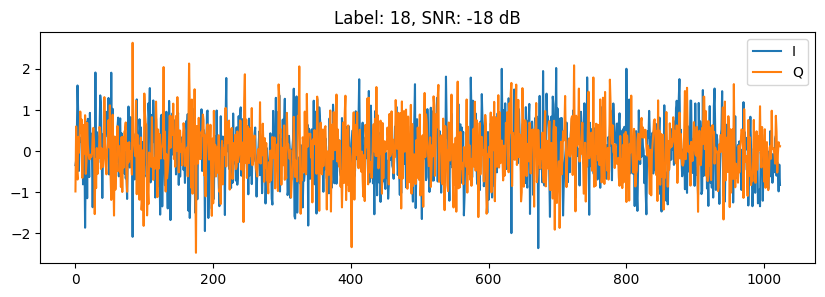

In [3]:
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Load the splits we just saved
splits = np.load("/content/capstone/radioML_2018/splits.npz")
train_idx = splits["train_idx"]
val_idx = splits["val_idx"]
test_idx = splits["test_idx"]

train_ds = RadioMLDataset(indices=train_idx)
val_ds = RadioMLDataset(indices=val_idx)
test_ds = RadioMLDataset(indices=test_idx)

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True, num_workers=4)

# Pull one batch and check shapes
iq_batch, label_batch, snr_batch = next(iter(train_loader))
print("IQ batch:", iq_batch.shape, iq_batch.dtype)
print("Label batch:", label_batch.shape, label_batch.dtype)
print("SNR batch:", snr_batch.shape, snr_batch.dtype)
print("Unique labels in batch:", torch.unique(label_batch))
print("SNR range in batch:", snr_batch.min().item(), "to", snr_batch.max().item())

# Plot I and Q for one sample
sample_iq = iq_batch[0]  # shape (2, 1024)
plt.figure(figsize=(10, 3))
plt.plot(sample_iq[0], label="I")
plt.plot(sample_iq[1], label="Q")
plt.title(f"Label: {label_batch[0].item()}, SNR: {snr_batch[0].item()} dB")
plt.legend()
plt.show()

#SECTION 4: MODEL ARCHITECTURE

In [4]:
import torch
import torch.nn as nn

class SEBlock1D(nn.Module):
    """Squeeze-and-excitation: learns per-channel weights based on global stats."""
    def __init__(self, n_filters):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)  # global average pool over time -> (B, C, 1)
        self.fc1 = nn.Linear(n_filters, n_filters // 2, bias=False)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(n_filters // 2, n_filters, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: (B, C, T)
        se = self.pool(x).squeeze(-1)      # (B, C)
        se = self.relu(self.fc1(se))
        se = self.sigmoid(self.fc2(se))    # (B, C), per-channel scale in [0,1]
        se = se.unsqueeze(-1)              # (B, C, 1) to broadcast over time
        return x * se


class ConvBlock(nn.Module):
    """One conv layer + ReLU + SE block, matching his conv_N + se_block_N pairing."""
    def __init__(self, in_ch, out_ch, kernel_size, dilation):
        super().__init__()
        padding = dilation * (kernel_size - 1) // 2  # "same" padding for odd kernels
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size, dilation=dilation, padding=padding)
        self.relu = nn.ReLU()
        self.se = SEBlock1D(out_ch)

    def forward(self, x):
        x = self.relu(self.conv(x))
        x = self.se(x)
        return x


class RadioMLClassifier(nn.Module):
    def __init__(self, n_classes=24):
        super().__init__()
        dilation_rates = [1, 2, 3, 2, 2, 2, 1]

        self.conv1 = ConvBlock(2, 32, 7, dilation_rates[0])
        self.conv2 = ConvBlock(32, 48, 5, dilation_rates[1])
        self.conv3 = ConvBlock(48, 64, 7, dilation_rates[2])
        self.conv4 = ConvBlock(64, 72, 5, dilation_rates[3])
        self.conv5 = ConvBlock(72, 84, 3, dilation_rates[4])
        self.conv6 = ConvBlock(84, 96, 3, dilation_rates[5])

        # conv_7 has no SE block in the original (use_se applies to conv 1-6 only)
        padding7 = dilation_rates[6] * (3 - 1) // 2
        self.conv7 = nn.Conv1d(96, 108, 3, dilation=dilation_rates[6], padding=padding7)
        self.relu7 = nn.ReLU()

        # Statistics pooling: mean and variance across time, concatenated
        self.fc1 = nn.Linear(108 * 2, 128)
        self.selu1 = nn.SELU()
        self.fc2 = nn.Linear(128, 128)
        self.selu2 = nn.SELU()
        self.out = nn.Linear(128, n_classes)

    def forward(self, x):
        # x: (B, 2, 1024)  -- channels-first, matches our Dataset's output
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.relu7(self.conv7(x))  # (B, 108, T)

        mean_pool = x.mean(dim=2)                      # (B, 108) -- global average
        var_pool = x.var(dim=2, unbiased=False)         # (B, 108) -- global variance
        pooled = torch.cat([mean_pool, var_pool], dim=1) # (B, 216)

        h = self.selu1(self.fc1(pooled))
        h = self.selu2(self.fc2(h))
        logits = self.out(h)  # raw logits; softmax applied by CrossEntropyLoss during training
        return logits

#SECTION 5: TRAINING LOOP

In [5]:
import torch.optim as optim
from torch.utils.data import DataLoader
import os
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = RadioMLClassifier(n_classes=24).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)  # matches Harper's LR
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=5)

BATCH_SIZE = 512
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

LATEST_PATH = "/content/capstone/radioML_2018/checkpoint_latest.pt"
BEST_PATH = "/content/capstone/radioML_2018/checkpoint_best.pt"

N_EPOCHS = 500
PATIENCE = 8  # stop if val_loss doesn't improve for this many epochs
start_epoch = 0
best_val_loss = float("inf")
epochs_no_improve = 0

# --- Resume logic: load latest checkpoint if one exists ---
if os.path.exists(LATEST_PATH):
    checkpoint = torch.load(LATEST_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_loss = checkpoint["best_val_loss"]
    epochs_no_improve = checkpoint["epochs_no_improve"]
    print(f"Resumed from epoch {start_epoch} (best_val_loss so far: {best_val_loss:.4f})")
else:
    print("No checkpoint found, starting fresh")

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for batch_idx, (iq, label, snr) in enumerate(loader):
            iq, label = iq.to(device), label.to(device)
            if train:
                optimizer.zero_grad()
            logits = model(iq)
            loss = criterion(logits, label)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * iq.size(0)
            correct += (logits.argmax(dim=1) == label).sum().item()
            total += iq.size(0)

            if batch_idx % 200 == 0:
                phase = "train" if train else "val"
                print(f"  [{phase}] batch {batch_idx}/{len(loader)} | "
                      f"running_loss={total_loss/total:.4f} running_acc={correct/total:.4f}")

    return total_loss / total, correct / total

for epoch in range(start_epoch, N_EPOCHS):
    start = time.time()
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    scheduler.step(val_loss)
    elapsed = time.time() - start

    improved = val_loss < best_val_loss
    if improved:
        best_val_loss = val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    print(f"Epoch {epoch+1}/{N_EPOCHS} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | {elapsed:.1f}s"
          f"{'  <- best' if improved else ''}")

    checkpoint = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "best_val_loss": best_val_loss,
        "epochs_no_improve": epochs_no_improve,
    }
    torch.save(checkpoint, LATEST_PATH)
    if improved:
        torch.save(checkpoint, BEST_PATH)

    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping: no improvement for {PATIENCE} epochs")
        break

Using device: cuda
Resumed from epoch 70 (best_val_loss so far: 1.1316)
  [train] batch 0/3495 | running_loss=1.0820 running_acc=0.6445
  [train] batch 200/3495 | running_loss=1.1258 running_acc=0.6283
  [train] batch 400/3495 | running_loss=1.1291 running_acc=0.6267
  [train] batch 600/3495 | running_loss=1.1274 running_acc=0.6273
  [train] batch 800/3495 | running_loss=1.1295 running_acc=0.6269
  [train] batch 1000/3495 | running_loss=1.1288 running_acc=0.6272
  [train] batch 1200/3495 | running_loss=1.1279 running_acc=0.6274
  [train] batch 1400/3495 | running_loss=1.1274 running_acc=0.6277
  [train] batch 1600/3495 | running_loss=1.1276 running_acc=0.6277
  [train] batch 1800/3495 | running_loss=1.1271 running_acc=0.6277
  [train] batch 2000/3495 | running_loss=1.1274 running_acc=0.6277
  [train] batch 2200/3495 | running_loss=1.1278 running_acc=0.6276
  [train] batch 2400/3495 | running_loss=1.1276 running_acc=0.6276
  [train] batch 2600/3495 | running_loss=1.1277 running_acc=0.62

KeyboardInterrupt: 

#SECTION 6: PER SNR EVALUATION

Loaded best checkpoint from epoch 103
Overall test accuracy: 0.6342
SNR -20 dB: 0.0422
SNR -18 dB: 0.0475
SNR -16 dB: 0.0465
SNR -14 dB: 0.0629
SNR -12 dB: 0.0890
SNR -10 dB: 0.1223
SNR  -8 dB: 0.1914
SNR  -6 dB: 0.2858
SNR  -4 dB: 0.3607
SNR  -2 dB: 0.4549
SNR  +0 dB: 0.5769
SNR  +2 dB: 0.6897
SNR  +4 dB: 0.8072
SNR  +6 dB: 0.9066
SNR  +8 dB: 0.9591
SNR +10 dB: 0.9787
SNR +12 dB: 0.9851
SNR +14 dB: 0.9860
SNR +16 dB: 0.9873
SNR +18 dB: 0.9870
SNR +20 dB: 0.9872
SNR +22 dB: 0.9871
SNR +24 dB: 0.9881
SNR +26 dB: 0.9867
SNR +28 dB: 0.9873
SNR +30 dB: 0.9868
Peak per-SNR accuracy: 0.9881


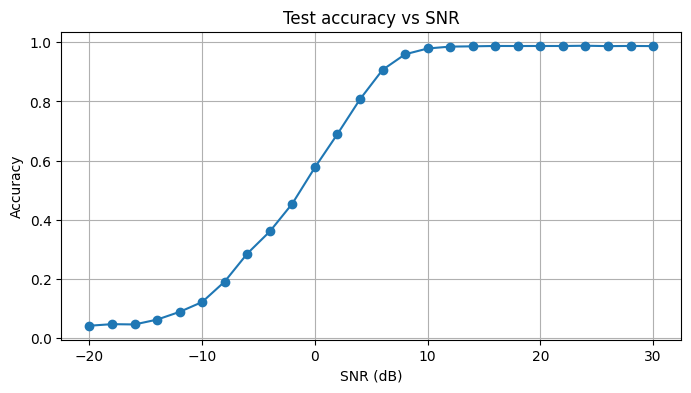

In [6]:
import matplotlib.pyplot as plt
from collections import defaultdict

# Load best checkpoint
ckpt = torch.load(BEST_PATH, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()
print("Loaded best checkpoint from epoch", ckpt["epoch"] + 1)

test_loader = DataLoader(test_ds, batch_size=512, shuffle=False, num_workers=4, pin_memory=True)

all_preds, all_labels, all_snrs = [], [], []
with torch.no_grad():
    for iq, label, snr in test_loader:
        preds = model(iq.to(device)).argmax(dim=1).cpu()
        all_preds.append(preds); all_labels.append(label); all_snrs.append(snr)

preds = torch.cat(all_preds).numpy()
labels = torch.cat(all_labels).numpy()
snrs = torch.cat(all_snrs).numpy()

print(f"Overall test accuracy: {(preds == labels).mean():.4f}")

snr_vals = np.unique(snrs)
snr_acc = [(preds[snrs == s] == labels[snrs == s]).mean() for s in snr_vals]
for s, a in zip(snr_vals, snr_acc):
    print(f"SNR {s:+3d} dB: {a:.4f}")
print(f"Peak per-SNR accuracy: {max(snr_acc):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(snr_vals, snr_acc, marker="o")
plt.xlabel("SNR (dB)"); plt.ylabel("Accuracy"); plt.grid(True)
plt.title("Test accuracy vs SNR")
plt.show()

#SECTION 7: ONNX EXPORT

In [8]:
import onnx, onnxruntime as ort

model_cpu = RadioMLClassifier(n_classes=24)
model_cpu.load_state_dict(torch.load(BEST_PATH, map_location="cpu")["model_state"])
model_cpu.eval()

ONNX_PATH = "/content/capstone/radioML_2018/radioml_amc.onnx"
dummy = torch.randn(1, 2, 1024)

torch.onnx.export(
    model_cpu, dummy, ONNX_PATH,
    input_names=["iq"], output_names=["logits"],
    dynamic_axes={"iq": {0: "batch"}, "logits": {0: "batch"}},
    opset_version=13,
    dynamo=False,
)
onnx.checker.check_model(onnx.load(ONNX_PATH))

x = torch.randn(8, 2, 1024)
with torch.no_grad():
    torch_out = model_cpu(x).numpy()
sess = ort.InferenceSession(ONNX_PATH)
onnx_out = sess.run(None, {"iq": x.numpy()})[0]
print("Max abs difference:", np.abs(torch_out - onnx_out).max())

/tmp/ipython-input-3773762825.py:10: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


Max abs difference: 1.5258789e-05


#PACKAGE VERSIONS

In [9]:
import torch, numpy, h5py, onnx, onnxruntime
print("torch", torch.__version__, "| numpy", numpy.__version__, "| h5py", h5py.__version__,
      "| onnx", onnx.__version__, "| onnxruntime", onnxruntime.__version__)

torch 2.9.0+cu126 | numpy 2.0.2 | h5py 3.15.1 | onnx 1.23.0 | onnxruntime 1.30.0
